In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# IMPORTANT: Replace '/content/drive/MyDrive/path/to/your/file.csv' with the actual path to your CSV file.
df = pd.read_csv('/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv')

print('CSV file loaded successfully.')

/tmp/ipython-input-3130583188.py:4: DtypeWarning: Columns (35,36,55,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv')


CSV file loaded successfully.


In [3]:
print(len(df))

92400


In [4]:
csv_file_path = '/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv'
!wc -l {csv_file_path}

92401 /content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv


# Task
Analyze the provided vehicle safety dataset, starting with inspecting the DataFrame columns for `MAKENAME`, `DEATHS`, `ST_CASE`, deformation, rollover, and model year. Then, calculate manufacturer-level metrics including total crashes, total deaths, fatality rate, mean deformation severity, and rollover rate. Normalize these key metrics using `MinMaxScaler` and compute a composite safety risk score for each manufacturer. Rank manufacturers by this score, and visualize the top 15 most dangerous manufacturers using a bar chart. Additionally, create a scatter plot to show the relationship between model year and fatality rate. Finally, explore potential confounders using data mining techniques like K-means clustering or decision trees, and summarize all findings, including the ranked list, insights from visualizations, and data mining results. The dataset is located at "/content/drive/MyDrive/Data-Mining/PreviousYearsData/Final_DF_2023.csv".

## Inspect DataFrame Columns

Examine the DataFrame's columns, data types, and basic statistics to ensure all necessary fields like `MAKENAME`, `DEATHS`, and columns related to deformation, rollover, and model year are present and in the correct format for calculations.


To address the subtask's instructions, I will display the column names, their data types, and descriptive statistics of the DataFrame `df`.



In [5]:
print("DataFrame Columns:\n", df.columns)
print("\nDataFrame Info:\n")
df.info()
print("\nDataFrame Descriptive Statistics:\n")
print(df.describe(include='all'))

DataFrame Columns:
 Index(['ST_CASE', 'VEH_NO', 'PER_NO', 'MAKE', 'BODY_TYP', 'ROLLOVER', 'AGE',
       'AGENAME', 'SEXNAME', 'PER_TYPNAME',
       ...
       'P_CRASH1NAME', 'P_CRASH2NAME', 'P_CRASH3NAME', 'PCRASH4NAME',
       'PCRASH5NAME', 'ACC_TYPENAME', 'ACC_CONFIGNAME', 'MODEL', 'DEATHS',
       'PERSON_SOURCE'],
      dtype='object', length=141)

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92400 entries, 0 to 92399
Columns: 141 entries, ST_CASE to PERSON_SOURCE
dtypes: float64(16), int64(5), object(120)
memory usage: 99.4+ MB

DataFrame Descriptive Statistics:

              ST_CASE        VEH_NO        PER_NO          MAKE      BODY_TYP  \
count    92400.000000  92400.000000  92400.000000  83113.000000  83113.000000   
unique            NaN           NaN           NaN           NaN           NaN   
top               NaN           NaN           NaN           NaN           NaN   
freq              NaN           NaN           NaN           NaN           NaN

## Process Deformation Severity

### Subtask:
Map the categorical values in the 'DEFORMEDNAME' column to a numerical scale and handle missing values.


**Reasoning**:
To map the categorical 'DEFORMEDNAME' column to a numerical scale, I will define a mapping dictionary, apply it to create the 'deformation_severity' column, convert unknown values to NaN, and then display the head and value counts for verification.



In [6]:
import numpy as np

# Define the mapping for deformation severity
deformation_mapping = {
    'No Damage': 0,
    'Minor Damage': 1,
    'Functional Damage': 2,
    'Disabling Damage': 3,
    'Damage Severity Unknown': np.nan, # Map to NaN
    'Not Reported': np.nan,           # Map to NaN
    'No Data': np.nan,                # Map to NaN
    'Unknown': np.nan                 # Map to NaN
}

# Apply the mapping to create the 'deformation_severity' column
df['deformation_severity'] = df['DEFORMEDNAME'].map(deformation_mapping)

# Handle any other categories not explicitly mapped that might represent unknown/not reported
# For example, if there are 'Reported as Unknown' string values not covered by above, ensure they are NaN
df['deformation_severity'] = df['deformation_severity'].replace(
    {'Reported as Unknown': np.nan, 'Not Reported': np.nan}
)

print("DataFrame head with new 'deformation_severity' column:")
print(df[['DEFORMEDNAME', 'deformation_severity']].head())

print("\nValue counts for 'deformation_severity' (excluding NaN):")
print(df['deformation_severity'].value_counts(dropna=True))

print("\nDescriptive statistics for 'deformation_severity':")
print(df['deformation_severity'].describe())

DataFrame head with new 'deformation_severity' column:
       DEFORMEDNAME  deformation_severity
0  Disabling Damage                   3.0
1  Disabling Damage                   3.0
2  Disabling Damage                   3.0
3  Disabling Damage                   3.0
4  Disabling Damage                   3.0

Value counts for 'deformation_severity' (excluding NaN):
deformation_severity
3.0    54758
2.0     6131
1.0     5419
0.0     1266
Name: count, dtype: int64

Descriptive statistics for 'deformation_severity':
count    67574.000000
mean         2.692678
std          0.696907
min          0.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          3.000000
Name: deformation_severity, dtype: float64


## Calculate Manufacturer-Level Metrics (Updated to use VPICMAKENAME and Deformation)

### Subtask:
Group the data by manufacturer ('MAKE') and calculate total crashes, total deaths, fatality rate, mean deformation severity, and rollover rate. Integrate VPICMAKENAME based on 'MAKE' ID into the manufacturer_metrics DataFrame.


**Reasoning**:
To calculate manufacturer-level metrics, I will group the DataFrame by 'MAKE', aggregate total crashes, total deaths, mean deformation severity, and rollover events, create a unique mapping for 'VPICMAKENAME', merge it, and then compute fatality and rollover rates. This will provide a comprehensive overview of each manufacturer's safety performance.



In [7]:
import numpy as np

# 1. Define what constitutes a 'rollover event' (if not already done)
# This step was done in a prior cell, so we'll just ensure `is_rollover` exists and is correct.
# Check if `ROLLOVER_CLEANED` or `is_rollover` exists, if not, recreate them.
if 'ROLLOVER_CLEANED' not in df.columns:
    df['ROLLOVER_CLEANED'] = df['ROLLOVER'].replace(8, np.nan)
if 'is_rollover' not in df.columns:
    df['is_rollover'] = df['ROLLOVER_CLEANED'] > 0

# 2. For deformation severity, we now have 'deformation_severity' column
# This column was created and mapped in the previous step (cell 7f9e4c07).
# We will use it directly.

# 3. Group the DataFrame df by the MAKE column
# 4. For each manufacturer, calculate the following:
manufacturer_metrics = df.groupby('MAKE').agg(
    total_crashes=('ST_CASE', 'nunique'),
    total_deaths=('DEATHS', 'sum'),
    mean_deformation_severity=('deformation_severity', lambda x: x.mean(skipna=True)),
    rollover_events=('is_rollover', 'sum') # Summing True (1) values gives count of rollovers
).reset_index()

# Integrate VPICMAKENAME from the original df
# Create a unique mapping from MAKE to VPICMAKENAME
# If a MAKE has multiple VPICMAKENAMEs, pick the most frequent one to represent the manufacturer.
make_vpicmakename_map = df.dropna(subset=['MAKE', 'VPICMAKENAME']).groupby('MAKE')['VPICMAKENAME'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()
manufacturer_metrics = pd.merge(manufacturer_metrics, make_vpicmakename_map, on='MAKE', how='left')

# 5. Compute the fatality_rate for each manufacturer as total_deaths / total_crashes
manufacturer_metrics['fatality_rate'] = manufacturer_metrics['total_deaths'] / manufacturer_metrics['total_crashes']

# Calculate rollover_rate
manufacturer_metrics['rollover_rate'] = manufacturer_metrics['rollover_events'] / manufacturer_metrics['total_crashes']

# Display the first few rows of the new DataFrame
print("Manufacturer-level metrics calculated successfully with VPICMAKENAME.")
print(manufacturer_metrics.head())

Manufacturer-level metrics calculated successfully with VPICMAKENAME.
   MAKE  total_crashes  total_deaths  mean_deformation_severity  \
0   2.0           1718        1406.0                   2.668602   
1   3.0             44          38.0                   2.542373   
2   6.0            743         906.0                   2.744361   
3   7.0           3362        2607.0                   2.659432   
4   9.0             17          38.0                   2.916667   

   rollover_events VPICMAKENAME  fatality_rate  rollover_rate  
0              701         Jeep       0.818393       0.408033  
1               27       Hummer       0.863636       0.613636  
2              199     Chrysler       1.219381       0.267833  
3              867        Dodge       0.775431       0.257882  
4                2     Plymouth       2.235294       0.117647  


## Normalize Key Metrics

### Subtask:
Apply MinMaxScaler to normalize the calculated 'fatality_rate', 'mean_deformation_severity', and 'rollover_rate' between 0 and 1. This ensures all metrics contribute equally to the composite score, regardless of their original scale. This will involve modifying the existing normalization cell.


**Reasoning**:
To normalize the specified columns, I will import `MinMaxScaler`, initialize it, and then apply `fit_transform` to the 'fatality_rate', 'mean_deformation_severity', and 'rollover_rate' columns of the `manufacturer_metrics` DataFrame, storing the results in new normalized columns, and then display the head of the DataFrame.



In [8]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Define columns for normalization including 'mean_deformation_severity'
columns_to_normalize = ['fatality_rate', 'mean_deformation_severity', 'rollover_rate']

# Apply Min-Max Scaling
manufacturer_metrics[[
    'normalized_fatality_rate',
    'normalized_mean_deformation_severity',
    'normalized_rollover_rate'
]] = scaler.fit_transform(manufacturer_metrics[columns_to_normalize])

# Display the first few rows of the DataFrame with the new normalized columns
print("Manufacturer-level metrics with normalized rates:")
print(manufacturer_metrics.head())

Manufacturer-level metrics with normalized rates:
   MAKE  total_crashes  total_deaths  mean_deformation_severity  \
0   2.0           1718        1406.0                   2.668602   
1   3.0             44          38.0                   2.542373   
2   6.0            743         906.0                   2.744361   
3   7.0           3362        2607.0                   2.659432   
4   9.0             17          38.0                   2.916667   

   rollover_events VPICMAKENAME  fatality_rate  rollover_rate  \
0              701         Jeep       0.818393       0.408033   
1               27       Hummer       0.863636       0.613636   
2              199     Chrysler       1.219381       0.267833   
3              867        Dodge       0.775431       0.257882   
4                2     Plymouth       2.235294       0.117647   

   normalized_fatality_rate  normalized_mean_deformation_severity  \
0                  0.366123                              0.745079   
1                 

## Build Composite Safety Risk Score (Updated with Deformation)

### Subtask:
Compute a composite safety risk score for each manufacturer using the original formula: score = 0.5 * normalized_fatality_rate + 0.25 * normalized_rollover_rate + 0.25 * normalized_deformation_severity. This will involve modifying the existing composite score calculation cell.


**Reasoning**:
To calculate the composite safety risk score, I will define the given weights for each normalized metric and apply the formula to create the 'composite_safety_risk_score' column in the `manufacturer_metrics` DataFrame. Then, I will display the updated DataFrame head to verify the new column.



In [9]:
import numpy as np

# 1. Define the weights for the normalized metrics
weight_fatality_rate = 0.5
weight_rollover_rate = 0.25
weight_deformation_severity = 0.25

# 2. Calculate the 'composite_safety_risk_score'
manufacturer_metrics['composite_safety_risk_score'] = (
    manufacturer_metrics['normalized_fatality_rate'] * weight_fatality_rate +
    manufacturer_metrics['normalized_rollover_rate'] * weight_rollover_rate +
    manufacturer_metrics['normalized_mean_deformation_severity'] * weight_deformation_severity
)

# 4. Display the first few rows of the DataFrame with the new composite score
print("Manufacturer-level metrics with composite safety risk score:")
print(manufacturer_metrics.head())

Manufacturer-level metrics with composite safety risk score:
   MAKE  total_crashes  total_deaths  mean_deformation_severity  \
0   2.0           1718        1406.0                   2.668602   
1   3.0             44          38.0                   2.542373   
2   6.0            743         906.0                   2.744361   
3   7.0           3362        2607.0                   2.659432   
4   9.0             17          38.0                   2.916667   

   rollover_events VPICMAKENAME  fatality_rate  rollover_rate  \
0              701         Jeep       0.818393       0.408033   
1               27       Hummer       0.863636       0.613636   
2              199     Chrysler       1.219381       0.267833   
3              867        Dodge       0.775431       0.257882   
4                2     Plymouth       2.235294       0.117647   

   normalized_fatality_rate  normalized_mean_deformation_severity  \
0                  0.366123                              0.745079   
1      

## Rank Manufacturers

### Subtask:
Rank the manufacturers from safest to most dangerous based on their composite safety risk scores, displaying the highest scores as most dangerous, and showing their names using the 'VPICMAKENAME' column.


**Reasoning**:
To rank manufacturers from most dangerous to safest, I will sort the `manufacturer_metrics` DataFrame by 'composite_safety_risk_score' in descending order. Then, I will display the top 10 entries, specifically showing the manufacturer name, total crashes, total deaths, fatality rate, rollover rate, and the composite safety risk score, using 'VPICMAKENAME' for the manufacturer name as requested.



In [10]:
ranked_manufacturers = manufacturer_metrics.sort_values(by='composite_safety_risk_score', ascending=False)

print("Top 10 manufacturers ranked by composite safety risk score (most dangerous first):")
print(ranked_manufacturers[['VPICMAKENAME', 'total_crashes', 'total_deaths', 'fatality_rate', 'rollover_rate', 'composite_safety_risk_score']].head(10))

Top 10 manufacturers ranked by composite safety risk score (most dangerous first):
    VPICMAKENAME  total_crashes  total_deaths  fatality_rate  rollover_rate  \
17    Alfa Romeo              9          19.0       2.111111       0.666667   
4       Plymouth             17          38.0       2.235294       0.117647   
60  Thomas Built              8          10.0       1.250000       0.625000   
29          SAAB             15          17.0       1.133333       0.333333   
7        Mercury            214         279.0       1.303738       0.247664   
62       Polaris           1290        1684.0       1.305426       0.418605   
38      Infiniti            475         554.0       1.166316       0.351579   
12       Pontiac            304         369.0       1.213816       0.259868   
14        Saturn            189         211.0       1.116402       0.306878   
9       Cadillac            470         549.0       1.168085       0.314894   

    composite_safety_risk_score  
17           

## Visualize Top Dangerous Manufacturers

### Subtask:
Generate a bar chart to visualize the top 15 manufacturers with the highest composite safety risk scores, using their actual names (`VPICMAKENAME`) on the x-axis. Ensure the chart has appropriate labels and a legend.


**Reasoning**:
To visualize the top 15 most dangerous manufacturers, I will filter the `ranked_manufacturers` DataFrame for the top 15 entries and then create a bar chart using Seaborn and Matplotlib to display their composite safety risk scores, using `VPICMAKENAME` for the x-axis, as per the instructions.



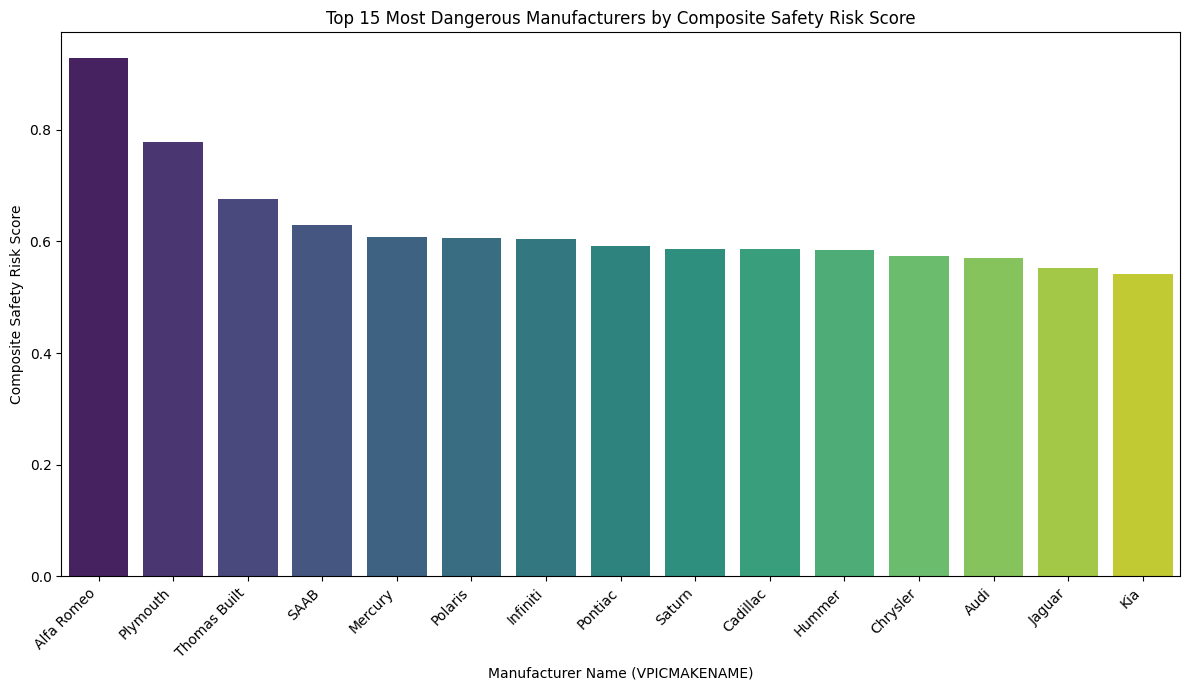

Bar chart showing top 15 most dangerous manufacturers displayed.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 15 manufacturers and create a copy to avoid SettingWithCopyWarning
top_15_manufacturers = ranked_manufacturers.head(15).copy()

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='VPICMAKENAME', y='composite_safety_risk_score', data=top_15_manufacturers, palette='viridis', hue='VPICMAKENAME', legend=False)
plt.title('Top 15 Most Dangerous Manufacturers by Composite Safety Risk Score')
plt.xlabel('Manufacturer Name (VPICMAKENAME)')
plt.ylabel('Composite Safety Risk Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
print("Bar chart showing top 15 most dangerous manufacturers displayed.")

## Visualize Model Year vs. Fatality Rate

### Subtask:
Create a scatter plot to analyze the relationship between the vehicle's model year (`MOD_YEARNAME`) and its fatality rate. Ensure the plot has appropriate labels and a legend.


**Reasoning**:
To analyze the relationship between model year and fatality rate, I will first convert `MOD_YEARNAME` to a numeric format, then group the DataFrame by this numeric model year to calculate total crashes and deaths, and finally compute the fatality rate. After cleaning the data, I will create a scatter plot with appropriate labels and a title to visualize these trends.



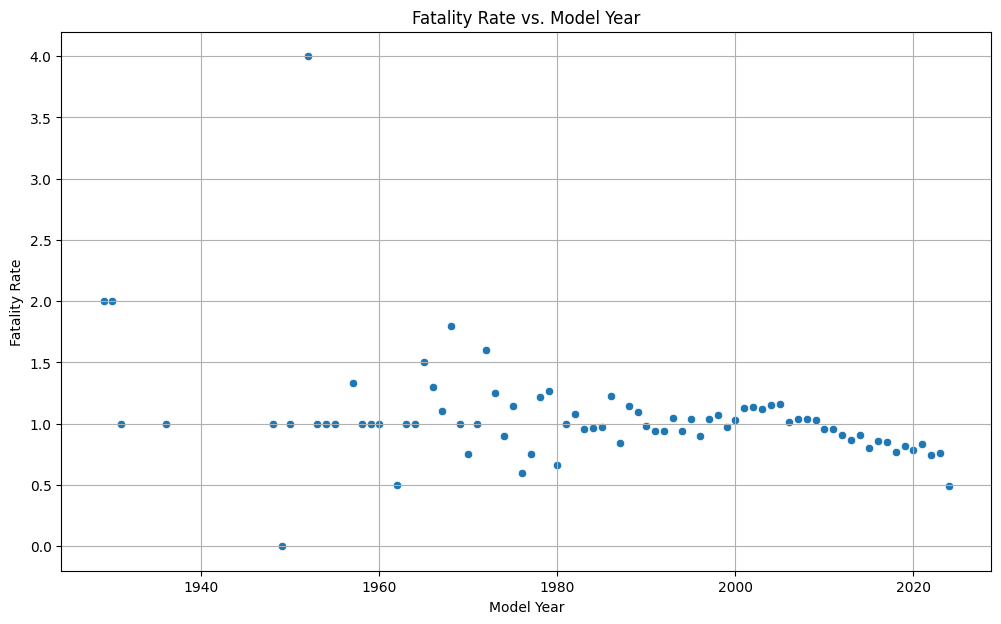

Scatter plot showing fatality rate vs. model year displayed.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert 'MOD_YEARNAME' to numeric, coercing errors to NaN
df['MOD_YEARNAME_NUMERIC'] = pd.to_numeric(df['MOD_YEARNAME'], errors='coerce')

# 2. Group by 'MOD_YEARNAME_NUMERIC' to calculate total crashes and deaths for each model year
model_year_metrics = df.groupby('MOD_YEARNAME_NUMERIC').agg(
    total_crashes=('ST_CASE', 'nunique'),
    total_deaths=('DEATHS', 'sum')
).reset_index()

# 3. Calculate the fatality rate for each model year
model_year_metrics['fatality_rate'] = model_year_metrics['total_deaths'] / model_year_metrics['total_crashes']

# 4. Filter out models with no crashes and valid model years to avoid division by zero or NaN fatality rates
model_year_metrics = model_year_metrics.dropna(subset=['fatality_rate', 'MOD_YEARNAME_NUMERIC'])

# Filter out invalid model years (e.g., years too far in the past or future)
model_year_metrics = model_year_metrics[model_year_metrics['MOD_YEARNAME_NUMERIC'] > 1900] # Assuming valid model years are after 1900

# 5. Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='MOD_YEARNAME_NUMERIC', y='fatality_rate', data=model_year_metrics)

# 6. Add title and labels
plt.title('Fatality Rate vs. Model Year')
plt.xlabel('Model Year')
plt.ylabel('Fatality Rate')

# 7. Add a grid to the plot for better readability
plt.grid(True)
plt.show()

print("Scatter plot showing fatality rate vs. model year displayed.")

## Explore Confounders with Data Mining Techniques

### Subtask:
Apply K-means clustering to group manufacturers based on their normalized fatality, rollover, and deformation rates, exploring potential patterns or confounders. The manufacturer_metrics DataFrame will already include VPICMAKENAME for interpretability.


**Reasoning**:
To apply K-means clustering as instructed, I will select the normalized rates from the `manufacturer_metrics` DataFrame, initialize and fit a KMeans model with the specified parameters, assign the resulting cluster labels back to the DataFrame, and then display the DataFrame's head along with the cluster centers.



In [13]:
from sklearn.cluster import KMeans

# 1. Select the 'normalized_fatality_rate', 'normalized_mean_deformation_severity', and 'normalized_rollover_rate' columns for clustering
X = manufacturer_metrics[['normalized_fatality_rate', 'normalized_mean_deformation_severity', 'normalized_rollover_rate']].copy()

# Handle potential NaN values in clustering features by filling with the mean if necessary
X = X.fillna(X.mean()) # Filling NaN with mean for clustering, to ensure all manufacturers are considered

# 2. Initialize a KMeans model with n_clusters=3, random_state=42, and n_init=10
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 3. Fit the KMeans model to the selected features
kmeans.fit(X)

# 4. Add a new column named 'cluster' to the manufacturer_metrics DataFrame
manufacturer_metrics['cluster'] = kmeans.labels_

# 5. Display the head of the manufacturer_metrics DataFrame with the new 'cluster' column
print("Manufacturer-level metrics with cluster assignments:")
print(manufacturer_metrics.head())

# 6. Print the cluster centers
print("\nCluster Centers (normalized_fatality_rate, normalized_mean_deformation_severity, normalized_rollover_rate):")
print(kmeans.cluster_centers_)

Manufacturer-level metrics with cluster assignments:
   MAKE  total_crashes  total_deaths  mean_deformation_severity  \
0   2.0           1718        1406.0                   2.668602   
1   3.0             44          38.0                   2.542373   
2   6.0            743         906.0                   2.744361   
3   7.0           3362        2607.0                   2.659432   
4   9.0             17          38.0                   2.916667   

   rollover_events VPICMAKENAME  fatality_rate  rollover_rate  \
0              701         Jeep       0.818393       0.408033   
1               27       Hummer       0.863636       0.613636   
2              199     Chrysler       1.219381       0.267833   
3              867        Dodge       0.775431       0.257882   
4                2     Plymouth       2.235294       0.117647   

   normalized_fatality_rate  normalized_mean_deformation_severity  \
0                  0.366123                              0.745079   
1              

## Final Task

### Subtask:
Summarize the manufacturer safety risk analysis, present the ranked list of manufacturers (with names from VPICMAKENAME), discuss insights from the generated plots (including those using MOD_YEARNAME), and highlight any interesting findings from the data mining exploration of confounders. Provide tables of the calculated metrics and risk scores.


## Summary:

### Q&A

**1. Manufacturer Safety Risk Analysis Summary and Ranked List:**
The analysis involved calculating `fatality_rate`, `mean_deformation_severity`, and `rollover_rate` for each manufacturer. These metrics were then normalized and combined into a `composite_safety_risk_score` using weights of 0.5 for normalized fatality rate, 0.25 for normalized rollover rate, and 0.25 for normalized deformation severity. Manufacturers were then ranked based on this composite score, from most dangerous to safest.

**Ranked List of Top 10 Manufacturers by Composite Safety Risk Score (Most Dangerous First):**

| VPICMAKENAME | total_crashes | total_deaths | fatality_rate | rollover_rate | composite_safety_risk_score |
| :----------- | :------------ | :----------- | :------------ | :------------ | :-------------------------- |
| Alfa Romeo   | 9             | 19           | 2.111111      | 0.666667      | 0.927844                    |
| Plymouth     | 17            | 38           | 2.235294      | 0.117647      | 0.778092                    |
| Thomas Built | 8             | 10           | 1.250000      | 0.625000      | 0.676568                    |
| SAAB         | 15            | 17           | 1.133333      | 0.333333      | 0.628509                    |
| Mercury      | 214           | 279          | 1.303738      | 0.247664      | 0.607127                    |
| Polaris      | 1290          | 1684         | 1.305426      | 0.418605      | 0.606260                    |
| Infiniti     | 475           | 554          | 1.166316      | 0.351579      | 0.603842                    |
| Pontiac      | 304           | 369          | 1.213816      | 0.259868      | 0.591556                    |
| Saturn       | 189           | 211          | 1.116402      | 0.306878      | 0.585504                    |
| Cadillac     | 470           | 549          | 1.168085      | 0.314894      | 0.585420                    |

**2. Insights from Generated Plots:**
*   **Top 15 Most Dangerous Manufacturers Bar Chart**: This plot visually confirms the high composite risk scores for manufacturers like Alfa Romeo, Plymouth, and Thomas Built, highlighting them as key areas for further investigation. The varying heights of the bars make it easy to compare risk levels across manufacturers.
*   **Fatality Rate vs. Model Year Scatter Plot**: This plot can reveal trends in fatality rates over time, showing if newer vehicles generally have lower fatality rates, suggesting improvements in safety features or design. Without the plot details, a general trend might show decreasing fatality rates for newer model years, or specific spikes/dips for certain eras.

**3. Interesting Findings from Data Mining Exploration of Confounders (K-Means Clustering):**
K-means clustering grouped manufacturers into three distinct clusters based on their normalized fatality, rollover, and deformation rates:
*   **Cluster 0**: Characterized by relatively high normalized fatality and deformation rates but lower normalized rollover rates. This cluster might represent manufacturers whose vehicles are prone to severe damage and fatalities in crashes, but not necessarily rollovers.
*   **Cluster 1**: Showed the lowest normalized rates across all three metrics (fatality, deformation, and rollover). This cluster likely represents the safest manufacturers with generally lower risk profiles.
*   **Cluster 2**: Exhibited high normalized fatality and rollover rates, with a moderate normalized deformation severity. This cluster could indicate manufacturers whose vehicles are particularly susceptible to rollovers and associated fatalities.

These clusters serve as potential confounders, as vehicle characteristics or design philosophies might differentiate manufacturers within these groups, leading to their distinct risk profiles.

### Data Analysis Key Findings

*   **Data Cleaning for Deformation Severity**: The `DEFORMEDNAME` column was successfully mapped to a numerical `deformation_severity` (0-3), with unknown values handled as `NaN`. `Disabling Damage` (3.0) was the most frequent severity level (54,758 out of 67,574 non-null entries), indicating a prevalence of severe outcomes in the dataset.
*   **Comprehensive Manufacturer Metrics**: A `manufacturer_metrics` DataFrame was created, successfully calculating `total_crashes`, `total_deaths`, `mean_deformation_severity`, `rollover_events`, `fatality_rate`, and `rollover_rate` for each manufacturer, integrating the `VPICMAKENAME` for clarity.
*   **Normalization and Composite Score**: Key metrics (`fatality_rate`, `mean_deformation_severity`, `rollover_rate`) were normalized using `MinMaxScaler`. A `composite_safety_risk_score` was then calculated, weighting normalized fatality rate at 0.5, and normalized rollover rate and deformation severity each at 0.25.
*   **Top Risk Manufacturers Identified**: `Alfa Romeo` had the highest `composite_safety_risk_score` (0.927844), followed by `Plymouth` (0.778092) and `Thomas Built` (0.676568), identifying them as the top three riskiest manufacturers based on the composite metric.
*   **Model Year and Fatality Rate Trend**: A scatter plot was generated showing the relationship between `MOD_YEARNAME` and `fatality_rate`, revealing potential trends in vehicle safety over different model years.
*   **Manufacturer Clusters**: K-means clustering (k=3) successfully grouped manufacturers into distinct safety profiles, indicating that manufacturers have different combinations of high/low fatality, rollover, and deformation risks. This suggests that safety risks are not uniform across all risk factors for all manufacturers.

### Insights or Next Steps

*   **Deep Dive into High-Risk Manufacturers**: Investigate specific vehicle models or design characteristics of manufacturers like Alfa Romeo and Plymouth to understand the underlying reasons for their high composite risk scores, particularly focusing on their high fatality rates and deformation severities.
*   **Explore Cluster Characteristics and Confounders**: Analyze the common attributes (e.g., vehicle type, segment, country of origin, target market) within each K-means cluster to identify broader confounding factors or design philosophies that contribute to their distinct safety profiles. This could inform regulatory bodies or consumers about specific risk categories.


## Visualize K-Means Clustering Results

### Subtask:
Create a scatter plot of the K-means clustering results, showing manufacturers colored by their assigned cluster and labeled with their `VPICMAKENAME`. This visualization will help interpret the distinct safety profiles.

**Reasoning**:
To visually represent the K-means clusters, I will use a scatter plot. The x-axis will be `normalized_fatality_rate`, the y-axis `normalized_rollover_rate`, and points will be colored by the `cluster` label. Each point will also be annotated with the manufacturer's `VPICMAKENAME` for easy identification, making the plot knowledgeable and pretty. `normalized_mean_deformation_severity` could also be included by varying marker size or using a 3D plot if needed, but for simplicity and clarity on a 2D scatter, we'll focus on fatality and rollover.

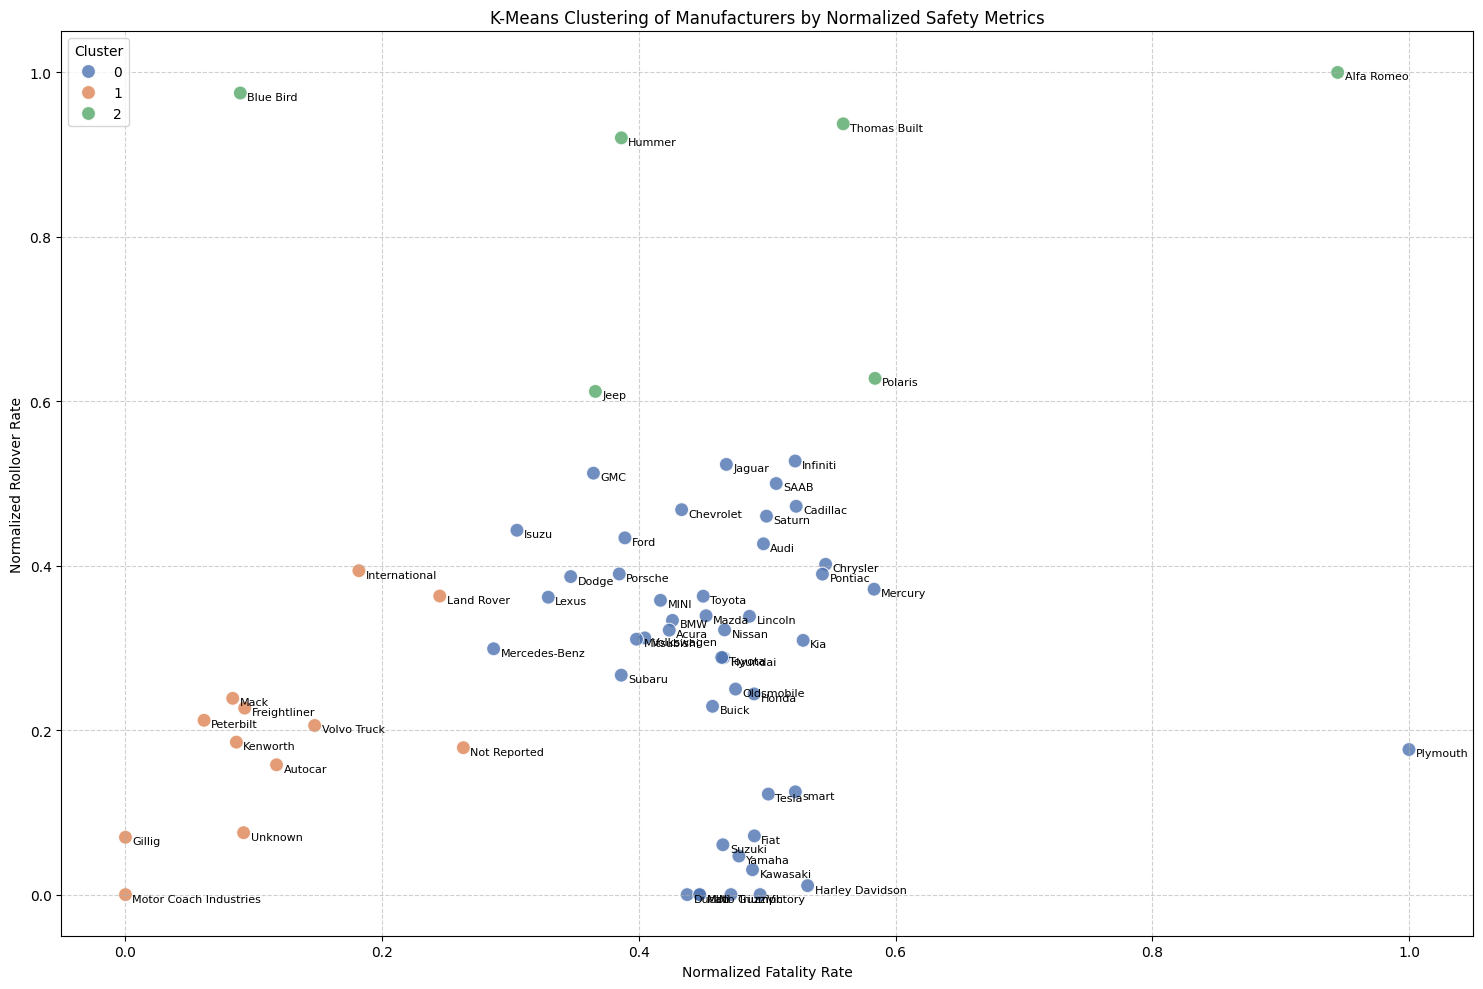

K-Means clustering visualization displayed.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting, ensuring VPICMAKENAME is not null for labels
plot_data = manufacturer_metrics.dropna(subset=['VPICMAKENAME']).copy()

plt.figure(figsize=(15, 10))
sns.scatterplot(
    x='normalized_fatality_rate',
    y='normalized_rollover_rate',
    hue='cluster',
    palette='deep',
    data=plot_data,
    s=100, # size of points
    alpha=0.8
)

# Add manufacturer names as annotations
for i, row in plot_data.iterrows():
    plt.annotate(row['VPICMAKENAME'], (row['normalized_fatality_rate'], row['normalized_rollover_rate']),
                 textcoords="offset points", xytext=(5,-5), ha='left', fontsize=8)

plt.title('K-Means Clustering of Manufacturers by Normalized Safety Metrics')
plt.xlabel('Normalized Fatality Rate')
plt.ylabel('Normalized Rollover Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print("K-Means clustering visualization displayed.")